In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt
from pathlib import Path
import albumentations as A
import cv2
import time


import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from albumentations.pytorch import ToTensorV2

from IPython.display import clear_output
import matplotlib.colors as mcolors
from scipy.ndimage import label
from skimage.segmentation import watershed
from torchvision.utils import make_grid

from Ellipses import *
from plottings import *
from metrics import *
from GRU import *

from load_dataset import *

%load_ext autoreload
%autoreload 2

# Parte 0

In [2]:
ellipses_sim = EllipsesSimulator(128, 5, 10)
frames, ground_truth = ellipses_sim.simulate(30)
frames_with_bboxes = visualize_ground_truth(frames, ground_truth)

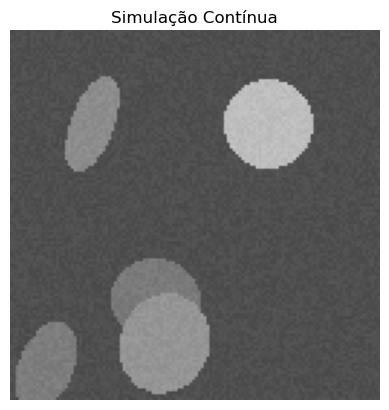

In [3]:
plot_simulation_frames(frames)

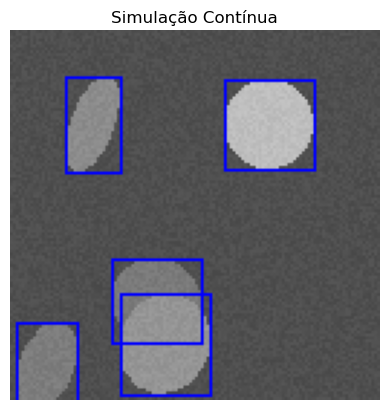

In [4]:
plot_simulation_frames(frames_with_bboxes)

In [5]:
frames_with_noisy_bboxes, noisy_annotations = create_noisy_bboxes(frames, ground_truth, 0.1)

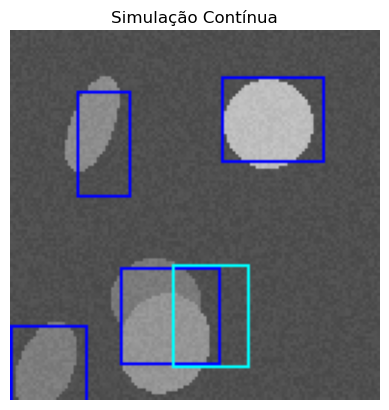

In [6]:
plot_simulation_frames(frames_with_noisy_bboxes)

In [7]:
print("Prints: (IDF1, Switches)")

# Caso (a)
print("IDF1 com predição = ground truth: ", compute_idf1(ground_truth, ground_truth))

# Caso (b)
preds_b = []
frame_k = 23

for linha in ground_truth:
    parts = linha.split(',')
    f = int(float(parts[0]))
    obj_id = int(float(parts[1]))
    
    # A partir do frame k, cruza as identidades 1 e 2
    if f >= frame_k:
        if obj_id == 1:
            parts[1] = '2'
        elif obj_id == 2:
            parts[1] = '1'
            
    preds_b.append(','.join(parts))

print("Duas identidades trocadas a partir do quadro k: ", compute_idf1(ground_truth, preds_b))

# Caso (c)
preds_c = []
frame_k = 30

for linha in ground_truth:
    parts = linha.split(',')
    f = int(float(parts[0]))
    obj_id = int(float(parts[1]))
    
    # A partir do frame k, a elipse 1 muda para um ID inventado
    if f >= frame_k and obj_id == 1:
        parts[1] = '99'
            
    preds_c.append(','.join(parts))

print("Uma track partida em duas no meio: ", compute_idf1(ground_truth, preds_c))

Prints: (IDF1, Switches)
IDF1 com predição = ground truth:  (np.float64(1.0), 0)
Duas identidades trocadas a partir do quadro k:  (np.float64(0.8933333333333333), 2)
Uma track partida em duas no meio:  (np.float64(0.9933333333333333), 1)


# Parte 1

In [83]:
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

def desnorm(img, mean=MEAN, std=STD):
    img_plot = img.cpu().permute(1, 2, 0).numpy()
    mean = np.array(mean)
    std = np.array(std)
    img_plot = (img_plot * std) + mean
    return np.clip(img_plot, 0, 1)

# Pipeline para redimensionamento das imagens
train_transform = A.Compose([
    # # Forca image e mask para 256x256
    # A.Resize(height=256, width=256),

    # # Padroniza o espectro de cores como cinza
    # A.ToGray(p=1.0),

    # # Normaliza os pixels para o padrao ImageNet
    # A.Normalize(mean=MEAN, std=STD),

    # Converte os arrays Numpy para Tensores do PyTorch e ajusta as dimensoes ((H, W, C) ==> (C, H, W))
    ToTensorV2()
])

batch_size = 1


# Definindo as sequencias para cada split
# Sao os numeros dos videos do dataset de treino oficial
train_videos = [2, 4, 5, 9, 10]
val_videos = [11, 13]

# Cria o Dataset de Treino (80% dos videos, ordem cronologica)
train_dataset = MOT17Dataset(
    root="features",
    model_base="SDP",
    sequences_list=train_videos,
    transform=train_transform,
    train_dataset=True
)

# Cria o Dataset de Validação (20% dos videos, ordem cronologica)
val_dataset = MOT17Dataset(
    root="features",
    model_base="SDP",
    sequences_list=val_videos,
    transform=train_transform,
    train_dataset=True  # Mantem True para carregar os GTs para calcular as metricas!
)

train_loader = DataLoader(train_dataset, batch_size=1, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False)

In [96]:
current_seq = None

frames_by_video = {}
ground_truth_SDP_by_video = {}
dets_SDP_by_video = {}
frames = []
ground_truth_SDP = []
dets_SDP = []
for batch_idx, (images, dets, gts, seq_names, frame_ids) in enumerate(train_loader):
    # O DataLoader insere uma dimensao extra por causa do batch. Extraimos aqui:
    image = images.squeeze(0)        # Formato final: [3, H, W]
    det = dets.squeeze(0)            # Formato final: [Num_Deteccoes, 5]
    gt = gts.squeeze(0)              # Formato final: [Num_Pessoas_Reais, 4]
    
    seq_name = seq_names[0]          # Extrai a string
    frame_id = frame_ids[0].item()   # Extrai o número do frame
    
    # --- DETECTOR DE MUDANÇA DE VIDEO ---
    if seq_name != current_seq:
        # Se tiver terminado um video valido, arquiva os dados dele
        if not current_seq is None:
            frames_by_video[current_seq] = frames
            ground_truth_SDP_by_video[current_seq] = ground_truth_SDP
            dets_SDP_by_video[current_seq] = dets_SDP

        frames = []
        ground_truth_SDP = []
        dets_SDP = []
        current_seq = seq_name
    
    frames.append(image.permute(1, 2, 0).numpy())
    gts_str = [
        ', '.join([
            *(row[:-1].int()).numpy().astype(str).tolist(),
            row[-1].numpy().astype(str).tolist()
        ])
        for row in gts[0]
    ]
    ground_truth_SDP.extend(gts_str)
    dets_str = [
        ', '.join([
            *(row[:-1].int()).numpy().astype(str).tolist(),
            row[-1].numpy().astype(str).tolist()
        ])
        for row in dets[0]
    ]
    dets_SDP.extend(dets_str)

In [106]:
def collate_fn(batch):
    """
    Agrupa os dados do batch numa tupla de listas.
    O batch recebe a saída do nosso __getitem__: (image, dets, gts, seq_name, frame_id)
    """
    return tuple(zip(*batch))

In [109]:
import torch
import torchvision
from torch.utils.data import DataLoader

# --- 1. CONFIGURACOES ---
device = 'cuda' if torch.cuda.is_available() else 'cpu'
MIN_CONFIDENCE = 0.5  # So aceita predicoes com mais de 50% de certeza

# Instancia o DataLoader (batch_size=1, shuffle=False para processar na ordem)
data_loader = DataLoader(train_dataset, batch_size=1, shuffle=False, collate_fn=collate_fn)

# --- 2. CARREGAR MODELO PRE-TREINADO ---
print("Carregando Faster R-CNN pre-treinado...")
model_rcnn = torchvision.models.detection.fasterrcnn_resnet50_fpn(
    weights='DEFAULT',
    box_score_thresh=0.5, # Filtra a confiança nativamente (padrão é 0.05)
    box_nms_thresh=0.5 # Deixa o NMS mais rigoroso (padrão é 0.5)
)
model_rcnn.to(device)
model_rcnn.eval()  # MODO INFERENCIA: Desliga calculo de gradientes e congela camadas (Dropout/BatchNorm)

# Dicionario para guardar as novas deteccoes: dict[seq_name][frame_id] = [bboxes]
novas_deteccoes = {}

print("Iniciando inferencia...")
# --- 3. LOOP DE INFERENCIA ---
with torch.no_grad():
    for batch_idx, (images, dets_publicas, gts, seq_names, frame_ids) in enumerate(data_loader):
        
        # O DataLoader com collate_fn entrega tuplas. Vamos pegar o primeiro elemento (batch 1)
        image = (images[0] / 255).to(device)
        seq_name = seq_names[0]
        frame_id = frame_ids[0]
        
        # Garante que a chave da sequencia existe no dicionario
        if seq_name not in novas_deteccoes:
            novas_deteccoes[seq_name] = []
        
        # O modelo em eval() recebe uma lista de imagens e retorna uma lista de dicionarios
        predictions = model_rcnn([image])[0] 
        
        # Extrai os resultados
        boxes = predictions['boxes'].cpu()   # [N, 4] no formato [x_min, y_min, x_max, y_max]
        labels = predictions['labels'].cpu() # [N] (1 = Pessoa, 3 = Carro, etc no COCO)
        scores = predictions['scores'].cpu() # [N] (de 0.0 a 1.0)
        
        frame_bboxes = []
        
        # --- 4. FILTRAGEM E CONVERSÃO ---
        for i in range(len(boxes)):
            # No dataset COCO (usado pelo torchvision), a classe 1 e 'person'
            if labels[i] == 1 and scores[i] >= MIN_CONFIDENCE:
                
                # Pega as coordenadas originais do Faster R-CNN
                x_min, y_min, x_max, y_max = boxes[i].tolist()
                
                # Converte para o padrão MOT: [x_canto, y_canto, largura, altura]
                w = x_max - x_min
                h = y_max - y_min
                x = x_min
                y = y_min
                conf = scores[i].item()
                
                # Salva no mesmo padrão 9 colunas que definimos antes
                # [frame, id(-1), x, y, w, h, conf, class(1), visibilidade(1.0)]
                bbox_formatada = [frame_id, -1, x, y, w, h, conf, 1.0, 1.0]
                frame_bboxes.append(bbox_formatada)
                
        # Guarda a lista de caixas no frame atual (mesmo que seja uma lista vazia)
        novas_deteccoes[seq_name].append(frame_bboxes)

print("\nInferencia concluida!")

Carregando Faster R-CNN pre-treinado...
Iniciando inferencia...

Inferencia concluida!


In [132]:
dets_rcnn_by_video = {
    name: [
        ', '.join([
            *[str(int(r)) for r in row[:-1]], 
            str(row[-1])
        ])
        for d in ds
        for row in d
    ]
    for name, ds in novas_deteccoes.items()
}

In [100]:
video_selected = "MOT17-02-SDP" # "MOT17-02-SDP", "MOT17-04-SDP", "MOT17-05-SDP", "MOT17-09-SDP"

frames = frames_by_video[video_selected]
ground_truth_SDP = ground_truth_SDP_by_video[video_selected]
dets_SDP = dets_SDP_by_video[video_selected]

In [ ]:
dets_rcnn = dets_rcnn_by_video[video_selected]

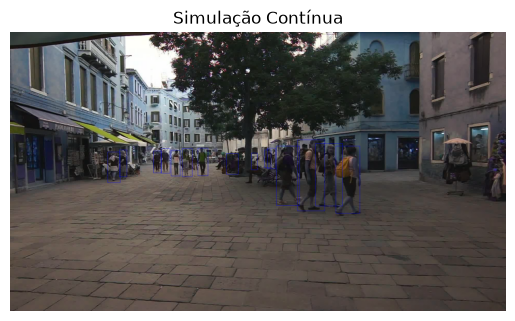

In [120]:
frames_with_bboxes_SDP = visualize_ground_truth_RGB(frames, dets_SDP)
plot_simulation_frames(frames_with_bboxes_SDP, delay=0)

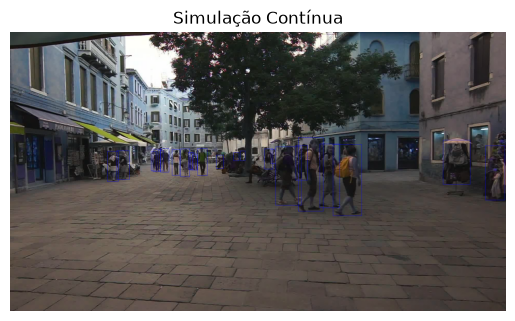

In [121]:
frames_with_bboxes_rcnn = visualize_ground_truth_RGB(frames, dets_rcnn)
plot_simulation_frames(frames_with_bboxes_rcnn)

In [122]:
dets_SDP_naive = [
    ', '.join(box[:-1].astype(int).astype(str))+f", {box[-1].astype(str)}" 
    for box in naive_tracker_shift(ground_truth_data=dets_SDP, threshold=0.5, max_age=10)
]

dets_rcnn_naive = [
    ', '.join(box[:-1].astype(int).astype(str))+f", {box[-1].astype(str)}" 
    for box in naive_tracker_shift(ground_truth_data=dets_rcnn, threshold=0.5, max_age=10)
]

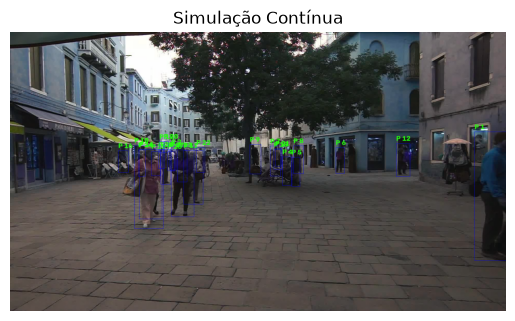

In [ ]:
frames_with_bboxes_SDP_naive = visualize_ground_truth_RGB(frames, dets_SDP_naive, put_id=True, fmt=lambda id: f"P {id}")
plot_simulation_frames(frames_with_bboxes_SDP_naive)

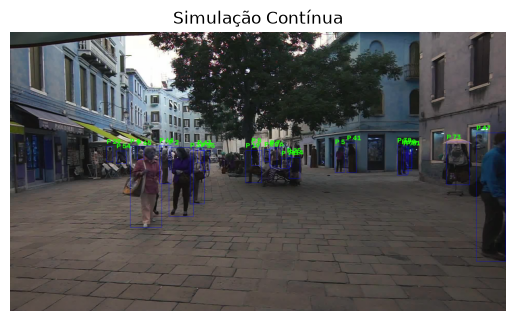

In [ ]:
frames_with_bboxes_rcnn_naive = visualize_ground_truth_RGB(frames, dets_rcnn_naive, put_id=True, fmt=lambda id: f"P {id}")
plot_simulation_frames(frames_with_bboxes_rcnn_naive)

In [123]:
metrics_1_3 = evaluate_trajectories(ground_truth=ground_truth_SDP, preds=dets_SDP_naive, threshold=0.5)
metrics_1_3

{'IDF1 Score': np.float64(0.34612839179351423),
 'ID Switches': 634,
 'Fragmentacoes': 1106,
 'Erro de Contagem de IDs': 485}

In [124]:
metrics_1_3 = evaluate_trajectories(ground_truth=ground_truth_SDP, preds=dets_rcnn_naive, threshold=0.5)
metrics_1_3

{'IDF1 Score': np.float64(0.2722906403940887),
 'ID Switches': 400,
 'Fragmentacoes': 551,
 'Erro de Contagem de IDs': 610}

### 4. Regras de Associação e Gestão de Trajetórias (Rastreador Ingênuo)

**1. Regra de Associação (Matching)**
A associação temporal entre objetos recorre à sobreposição espacial e a uma estratégia de otimização local, baseada nas seguintes regras:

* **Métrica de Custo:** Utiliza-se a **Interseção sobre a União (IoU)** entre as caixas delimitadoras (*bounding boxes*) das trajetórias ativas na memória e as novas detecções do quadro atual (\(t\)).
* **Estratégia de Resolução:** Aplica-se o algoritmo de **Matching Guloso (*Greedy Match*)**. O algoritmo procura iterativamente na matriz de IoU o valor global máximo, associando esse par (memória \(\leftrightarrow\) detecção). Após o pareamento, a respectiva linha e coluna são invalidadas, e o processo repete-se para os restantes candidatos até esgotar as opções.
* **Limiar Fixo (Corte):** Para evitar associações espúrias entre objetos distantes ou sobrepostos acidentalmente, a correspondência só é validada se o valor de IoU do par guloso for maior ou igual a um limiar fixo pré-definido (por padrão, $0.5$). Pareamentos abaixo deste valor são rejeitados.

**2. Gestão de Nascimento de Tracks**
Uma trajetória é considerada nova (nascimento) sempre que uma detecção no quadro \(t\) não consegue ser associada a nenhuma identidade pré-existente. Isto ocorre em duas situações:

* Não há sobreposição geométrica suficiente com nenhuma trajetória ativa (IoU inferior ao limiar).
* Todas as trajetórias ativas na vizinhança já foram "consumidas" pelo algoritmo guloso por possuírem maior IoU com outras detecções.

Quando o nascimento ocorre, o sistema atribui um **Identificador (ID) sequencial inédito** à detecção, inicializa o seu contador de idade (quadros sem observação) a $0$ e adiciona-a ao registro de memórias ativas.

**3. Gestão de Morte de Tracks (Memória e Tolerância)**
O rastreador não descarta imediatamente um objeto que deixe de ser detectado (por exemplo, devido a uma oclusão momentânea ou falha temporal do detector R-CNN). Existe um mecanismo de tolerância regulado pelo parâmetro \(K\) (`max_age`):

* **Envelhecimento:** Se uma trajetória presente na memória não for associada a nenhuma detecção no quadro \(t\), a sua última caixa delimitadora conhecida fica temporalmente **congelada** na mesma posição espacial, e o seu contador de idade é incrementado em \(+1\).
* **Rejuvenescimento:** Se em quadros seguintes o objeto voltar a ser detectado e o IoU com a caixa "fantasma" congelada for superior ao limiar, a associação é restabelecida. A posição espacial é atualizada com a nova detecção e a idade retorna a $0$.
* **Morte Definitiva:** Se uma trajetória acumular um número de quadros consecutivos sem observação igual ou superior ao limite de tolerância (\(K\)), o objeto é declarado **morto** e a trajetória é eliminada permanentemente da memória. Um reaparecimento futuro do mesmo objeto resultará num novo nascimento e, consequentemente, numa troca de identidade explícita (*ID Switch*).

In [148]:
def avaliar_todas_sequencias(dicionario_dados_brutos, limiares_map=np.arange(0.5, 0.96, 0.05)):
    """
    Processa todas as sequencias, roda o rastreador e extrai IDF1 e mAP reais.
    dicionario_dados_brutos = {'MOT17-04': {'gt': [...], 'preds': [...]}, ...}
    """
    resultados = {}
    
    for seq_name, dados in dicionario_dados_brutos.items():
        ground_truth = dados['gt']
        predicoes = dados['preds']
        
        # Metricas Temporais (O codigo que montamos anteriormente)
        traj_metrics = evaluate_trajectories(ground_truth, predicoes, threshold=0.5)
        
        # Calculo do mAP
        parts_t = np.array([list(map(float, x.split(','))) for x in ground_truth])
        parts_p = np.array([list(map(float, x.split(','))) for x in predicoes])
        
        num_frames = int(max(np.max(parts_t[:, 0]) if len(parts_t) > 0 else 0, 
                             np.max(parts_p[:, 0]) if len(parts_p) > 0 else 0))
        
        tp_total = {limiar: 0 for limiar in limiares_map}
        fp_total = {limiar: 0 for limiar in limiares_map}
        fn_total = {limiar: 0 for limiar in limiares_map}
        
        # Processamento Frame a Frame para Detecao (mAP)
        for f in range(1, num_frames + 1):
            frame_t = parts_t[parts_t[:, 0] == f]
            frame_p = parts_p[parts_p[:, 0] == f]
            
            if len(frame_t) == 0 and len(frame_p) == 0:
                continue
                
            iou_matrix = calculate_iou_matrix(frame_p, frame_t) if len(frame_p) > 0 and len(frame_t) > 0 else np.zeros((len(frame_p), len(frame_t)))
            
            # Avalia para cada limiar do mAP (0.50 a 0.95)
            for limiar in limiares_map:
                matches_iou, _ = greedy_match(iou_matrix, len(frame_p), len(frame_t))
                tp = (matches_iou >= limiar).sum()
                tp_total[limiar] += tp
                fp_total[limiar] += len(frame_p) - tp
                fn_total[limiar] += len(frame_t) - tp
                
        # Calcula a Average Precision (AP) para cada limiar e extrai a media (mAP)
        ap_por_limiar = []
        for limiar in limiares_map:
            tp = tp_total[limiar]
            fp = fp_total[limiar]
            fn = fn_total[limiar]
            ap = tp / (tp + fp + fn) if (tp + fp + fn) > 0 else 0
            ap_por_limiar.append(ap)
            
        map_final = np.mean(ap_por_limiar)
        
        # Densidade (Eixo de dificuldade)
        densidade_media = len(parts_t) / num_frames if num_frames > 0 else 0
        
        # Consolida os dados da sequencia
        num_trues = len(np.unique(parts_t[:, 1])) if len(parts_t) > 0 else 1
        num_preds = len(np.unique(parts_p[:, 1])) if len(parts_p) > 0 else 0
        
        resultados[seq_name] = {
            'mAP': map_final,
            'IDF1': traj_metrics['IDF1 Score'],
            'num_preds': num_preds,
            'num_trues': num_trues,
            'id_switches': traj_metrics['ID Switches'],
            'densidade': densidade_media
        }
        
    return resultados


def plotar_descolamento(resultados_sequencias, model: str):
    # Ordenacao estrita pelo eixo de dificuldade (Densidade)
    sequencias_ordenadas = sorted(resultados_sequencias.items(), key=lambda x: x[1]['densidade'])
    
    nomes_seqs = [seq[0] for seq in sequencias_ordenadas]
    map_vals = [seq[1]['mAP'] for seq in sequencias_ordenadas]
    idf1_vals = [seq[1]['IDF1'] for seq in sequencias_ordenadas]
    
    # Razoes para quantificar o fracasso
    razao_ids = [seq[1]['num_preds'] / seq[1]['num_trues'] for seq in sequencias_ordenadas]
    switches_por_id_real = [seq[1]['id_switches'] / seq[1]['num_trues'] for seq in sequencias_ordenadas]

    # Estrutura de duplo painel
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
    fig.suptitle(f'{model} - Quantificação do Fracasso: O Descolamento do Rastreador Ingénuo', fontsize=14, fontweight='bold')

    # Painel 1: mAP vs IDF1
    ax1.plot(nomes_seqs, map_vals, marker='o', color='royalblue', linewidth=2, label='mAP (Deteção)')
    ax1.plot(nomes_seqs, idf1_vals, marker='s', color='darkorange', linewidth=2, label='IDF1 (Trajetória)')
    ax1.set_ylabel('Pontuação', fontsize=11)
    ax1.set_title('Desempenho Geral (Deteção vs Associação)', fontsize=12)
    ax1.set_ylim(0, 1.0)
    ax1.grid(True, linestyle='--', alpha=0.6)
    ax1.legend(loc='lower left')

    # Painel 2: Explosao de IDs e Switches
    ax2.plot(nomes_seqs, razao_ids, marker='^', color='firebrick', linewidth=2, label='IDs Previstos / IDs Verdadeiros')
    ax2.plot(nomes_seqs, switches_por_id_real, marker='D', color='purple', linewidth=2, label='ID Switches / ID Verdadeiro')
    ax2.axhline(y=1.0, color='gray', linestyle=':', label='Razão Ideal (1.0 = Sem Fragmentação/Switches)')
    ax2.set_xlabel('Sequências de Vídeo (Dificuldade Crescente → Pessoas por Quadro)', fontsize=11, fontweight='bold')
    ax2.set_ylabel('Taxa / Multiplicador', fontsize=11)
    ax2.set_title('Descolamento da Identidade', fontsize=12)
    ax2.grid(True, linestyle='--', alpha=0.6)
    ax2.legend(loc='upper left')

    plt.tight_layout()
    plt.subplots_adjust(top=0.92)
    plt.show()

In [149]:
# Estrutura os dados para a funcao
eval_SDP = {
    name: {"gt": ground_truth_SDP_by_video[name], "preds": dets_SDP_by_video[name]}
    for name in ground_truth_SDP_by_video.keys()
}

eval_rcnn = {
    name: {"gt": ground_truth_SDP_by_video[name], "preds": dets_rcnn_by_video[name]}
    for name in ground_truth_SDP_by_video.keys()
}

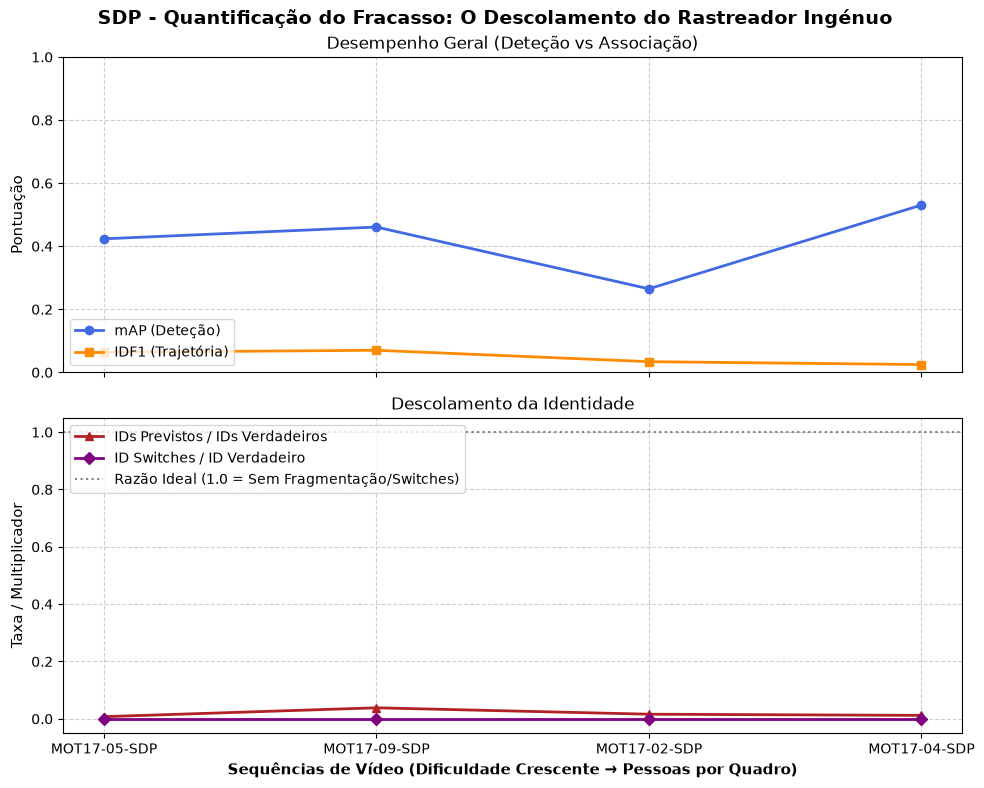

In [150]:
resultados_SDP = avaliar_todas_sequencias(eval_SDP)
plotar_descolamento(resultados_SDP, model="SDP")

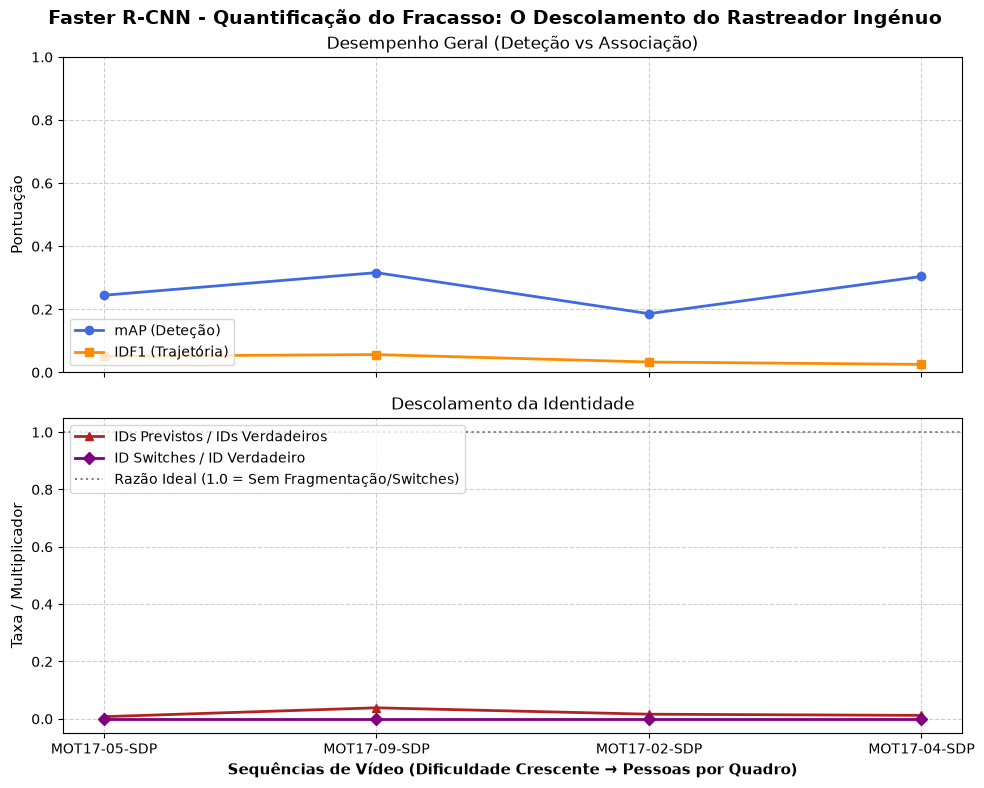

In [151]:
resultados_rcnn = avaliar_todas_sequencias(eval_rcnn)
plotar_descolamento(resultados_rcnn, model="Faster R-CNN")

---

# Parte 2

In [8]:
# Configurações iniciais
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
modelo = BBoxTrackerGRU(input_size=4, hidden_size=64).to(device)
criterion = torch.nn.SmoothL1Loss()
optimizer = torch.optim.Adam(modelo.parameters(), lr=0.005)

T = 8 # Tamanho da janela de BPTT
NUM_ELIPSES = 3 # Quantidade de objetos simultâneos

print("Iniciando treinamento com Normalização e Múltiplos Objetos...")

for epoca in range(150): # Aumentamos um pouco as épocas para garantir convergência
    # 1. Gera vídeo com 3 elipses
    simulador = EllipsesSimulator(img_size=128, num_obj=NUM_ELIPSES, dur_occlusion=10, speed=2)
    _, gt_treino = simulador.simulate(num_frames=60)
    
    # 2. Converte para Tensor. Shape: (3, 60, 4)
    trajetorias_tensor = parse_gt_to_tensor_all(gt_treino, num_ids=NUM_ELIPSES)
    
    # 3. Fatiador de Janelas. Para 3 objetos e T=8, teremos batch maior
    # Achata a dimensão de objetos e quadros para tratar tudo como amostras de treino
    inputs_batch, targets_batch = preparar_janelas_treino(trajetorias_tensor.reshape(-1, 4), T)
    
    # === NORMALIZAÇÃO CRÍTICA ===
    inputs_batch = (inputs_batch / 128.0).to(device)
    targets_batch = (targets_batch / 128.0).to(device)
    
    # 4. Treinamento
    estado_oculto_zerado = modelo.init_hidden(batch_size=inputs_batch.size(0), device=device)
    optimizer.zero_grad()
    
    caixas_previstas, _ = modelo(inputs_batch, estado_oculto_zerado)
    
    loss = criterion(caixas_previstas, targets_batch)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(modelo.parameters(), max_norm=1.0)
    optimizer.step()
    
    if epoca % 30 == 0:
        print(f"Época {epoca:03d} | Erro Normalizado: {loss.item():.5f}")

print("Treino concluído! Testando no cenário com oclusões...")

c:\Users\walle\anaconda3\Lib\site-packages\torch\cuda\__init__.py:228: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 10020). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\c10\cuda\CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


Iniciando treinamento com Normalização e Múltiplos Objetos...
Época 000 | Erro Normalizado: 0.07102
Época 030 | Erro Normalizado: 0.00186
Época 060 | Erro Normalizado: 0.00301
Época 090 | Erro Normalizado: 0.00180
Época 120 | Erro Normalizado: 0.00211
Treino concluído! Testando no cenário com oclusões...


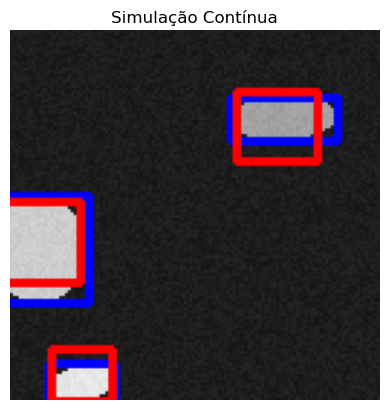

In [9]:

# --- VISUALIZAÇÃO ---
modelo.eval()

# Cria vídeo novo com 3 elipses
simulador_teste = EllipsesSimulator(img_size=128, num_obj=NUM_ELIPSES, dur_occlusion=10, speed=2)
frames_teste, gt_teste = simulador_teste.simulate(num_frames=40)

# Shape: (3, 40, 4)
traj_teste_tensor = parse_gt_to_tensor_all(gt_teste, num_ids=NUM_ELIPSES)

todas_previsoes = []
todos_targets = []

# Inferência feita de forma sequencial para cada objeto (como será no MOT17)
with torch.no_grad():
    for obj_idx in range(NUM_ELIPSES):
        # Isola a trajetória de 1 objeto. Shape: (1, 40, 4)
        traj_obj = traj_teste_tensor[obj_idx:obj_idx+1]
        
        inputs_teste, targets_teste = preparar_janelas_treino(traj_obj[0], T)
        
        # === NORMALIZAÇÃO CRÍTICA NA INFERÊNCIA ===
        inputs_teste = (inputs_teste / 128.0).to(device)
        
        estado_oculto = modelo.init_hidden(batch_size=inputs_teste.size(0), device=device)
        previsoes_norm, _ = modelo(inputs_teste, estado_oculto)
        
        # === DESNORMALIZAÇÃO === (Volta para a escala de pixels)
        previsoes = previsoes_norm * 128.0
        
        todas_previsoes.append(previsoes.cpu().numpy())
        todos_targets.append(targets_teste.numpy()) # O target real mantemos em pixels originais

# Transforma as listas de volta em arrays NumPy para desenhar. Shape: (3, seq_len, 4)
array_reais = np.stack(todos_targets)
array_previstos = np.stack(todas_previsoes)

# Desenha as caixas das 3 elipses
frames_finais = render_gru_predictions_multi(frames_teste, array_reais, array_previstos, janela_T=T)

# Roda a sua animação nativa
plot_simulation_frames(frames_finais)

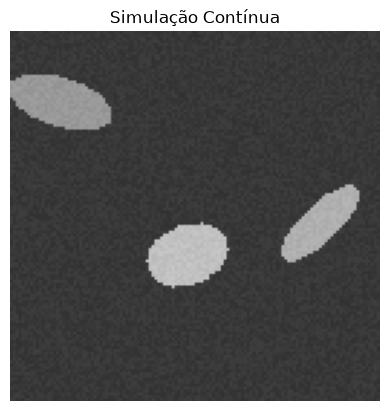

In [24]:
# Plota o vídeo original, contendo apenas o fundo cinza e a(s) elipse(s)
plot_simulation_frames(frames_teste)

In [ ]:
# Descobre a resolução real da sequência atual do MOT17 (ex: 1920x1080)
img_h, img_w = frames[0].shape[:2]

# Roda o rastreador GRU para as detecções públicas (SDP)
dets_SDP_gru = [
    ', '.join(box[:-1].astype(float).astype(int).astype(str)) + f", {box[-1]}" 
    for box in gru_tracker_shift(ground_truth_data=dets_SDP, model=modelo, device=device, img_w=img_w, img_h=img_h, threshold=0.5, max_age=10)
]

# Roda o rastreador GRU para as detecções do Faster R-CNN
dets_rcnn_gru = [
    ', '.join(box[:-1].astype(float).astype(int).astype(str)) + f", {box[-1]}" 
    for box in gru_tracker_shift(ground_truth_data=dets_rcnn, model=modelo, device=device, img_w=img_w, img_h=img_h, threshold=0.5, max_age=10)
]

# Compara as métricas do modelo GRU vs o modelo Ingênuo da Parte 1
metrics_SDP_naive = evaluate_trajectories(ground_truth=ground_truth_SDP, preds=dets_SDP_naive, threshold=0.5)
metrics_SDP_gru   = evaluate_trajectories(ground_truth=ground_truth_SDP, preds=dets_SDP_gru, threshold=0.5)

print("--- COMPARAÇÃO DE RESULTADOS SDP ---")
print("Ingênuo:", metrics_SDP_naive)
print("RNN/GRU:", metrics_SDP_gru)

# Se quiser ver a mágica funcionando visualmente
frames_with_bboxes_gru = visualize_ground_truth_RGB(frames, dets_SDP_gru, put_id=True, fmt=lambda id: f"GRU {id}")
plot_simulation_frames(frames_with_bboxes_gru)